# 03 - Computer Vision with YOLO

This notebook implements the Computer Vision component of CarCare AI using the CarParts-Seg dataset and a YOLO segmentation model.

The goal is to identify and segment visible vehicle parts from an input image.

The detected vehicle part can later be combined with a user's maintenance question and passed to the RAG pipeline.

### Pipeline

```text
Vehicle Image
      ↓
YOLO Segmentation Model
      ↓
Detected Vehicle Part
      ↓
Part Name + User Question
      ↓
RAG Pipeline
      ↓
Ollama
      ↓
Grounded Maintenance Answer
```

### Main Tasks

1. Load and inspect the CarParts-Seg dataset.
2. Verify the YOLO dataset configuration.
3. Train a YOLO segmentation model.
4. Evaluate the trained model.
5. Test predictions on vehicle images.
6. Extract detected vehicle-part names.
7. Save the trained model for backend integration.


In [6]:
from pathlib import Path
import yaml

PROJECT_ROOT = Path.cwd().parent
DATASET_DIR = PROJECT_ROOT / "Data" / "carparts-seg"
DATASET_YAML = DATASET_DIR / "carparts-seg.yaml"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset directory: {DATASET_DIR}")
print(f"YAML file: {DATASET_YAML}")

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory not found:\n{DATASET_DIR}"
    )

if not DATASET_YAML.exists():
    raise FileNotFoundError(
        f"Dataset YAML not found:\n{DATASET_YAML}"
    )

print("\nDataset directory exists: True")
print("YAML file exists: True")

Project root: e:\CarCare_AI
Dataset directory: e:\CarCare_AI\Data\carparts-seg
YAML file: e:\CarCare_AI\Data\carparts-seg\carparts-seg.yaml

Dataset directory exists: True
YAML file exists: True


In [3]:
with open(DATASET_YAML, "r", encoding="utf-8") as f:
    dataset_config = yaml.safe_load(f)

print("Dataset YAML loaded successfully.\n")

print("Dataset path:")
print(dataset_config.get("path"))

print("\nTrain:")
print(dataset_config.get("train"))

print("\nValidation:")
print(dataset_config.get("val"))

print("\nTest:")
print(dataset_config.get("test"))

class_names = dataset_config.get("names", {})

print(f"\nNumber of classes: {len(class_names)}")

print("\nClasses:")
for class_id, class_name in class_names.items():
    print(f"{class_id}: {class_name}")

Dataset YAML loaded successfully.

Dataset path:
C:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\Data\carparts-seg

Train:
images/train

Validation:
images/val

Test:
images/test

Number of classes: 23

Classes:
0: back_bumper
1: back_door
2: back_glass
3: back_left_door
4: back_left_light
5: back_light
6: back_right_door
7: back_right_light
8: front_bumper
9: front_door
10: front_glass
11: front_left_door
12: front_left_light
13: front_light
14: front_right_door
15: front_right_light
16: hood
17: left_mirror
18: object
19: right_mirror
20: tailgate
21: trunk
22: wheel


## Dataset Verification

The CarParts-Seg dataset uses YOLO segmentation annotations.

Before training, the dataset structure will be verified by checking:

* Training images and labels
* Validation images and labels
* Test images and labels
* Image-label correspondence
* Empty label files

This ensures that the dataset is correctly prepared for YOLO segmentation training.


In [4]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

splits = {
    "train": DATASET_DIR / "images" / "train",
    "val": DATASET_DIR / "images" / "val",
    "test": DATASET_DIR / "images" / "test",
}

for split_name, image_dir in splits.items():
    label_dir = DATASET_DIR / "labels" / split_name

    images = [
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in image_extensions
    ]

    labels = list(label_dir.glob("*.txt"))

    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    missing_labels = image_stems - label_stems
    orphan_labels = label_stems - image_stems

    empty_labels = [
        p for p in labels
        if p.stat().st_size == 0
    ]

    print("=" * 70)
    print(f"{split_name.upper()} SPLIT")
    print(f"Images: {len(images)}")
    print(f"Labels: {len(labels)}")
    print(f"Missing labels: {len(missing_labels)}")
    print(f"Orphan labels: {len(orphan_labels)}")
    print(f"Empty labels: {len(empty_labels)}")

TRAIN SPLIT
Images: 3156
Labels: 3156
Missing labels: 0
Orphan labels: 0
Empty labels: 116
VAL SPLIT
Images: 401
Labels: 401
Missing labels: 0
Orphan labels: 0
Empty labels: 12
TEST SPLIT
Images: 276
Labels: 276
Missing labels: 0
Orphan labels: 0
Empty labels: 7


## YOLO Segmentation Model

The CarParts-Seg dataset contains polygon-based segmentation annotations for 23 vehicle-part classes.

A lightweight YOLO segmentation model will be used as the baseline model.

The model will be trained to:

* detect visible vehicle parts,
* generate segmentation masks,
* classify each detected part into one of the 23 classes.

The trained model will later be used by CarCare AI to identify a vehicle part from an uploaded image.


In [5]:
import ultralytics
from ultralytics import YOLO

print(f"Ultralytics version: {ultralytics.__version__}")

MODEL_NAME = "yolo11n-seg.pt"

model = YOLO(MODEL_NAME)

print(f"Model loaded: {MODEL_NAME}")

Ultralytics version: 8.4.159
Model loaded: yolo11n-seg.pt


In [6]:
from ultralytics.data.utils import check_det_dataset

dataset_info = check_det_dataset(str(DATASET_YAML))

print("YOLO dataset configuration loaded successfully.")
print(f"Number of classes: {dataset_info['nc']}")
print(f"Class names: {dataset_info['names']}")

YOLO dataset configuration loaded successfully.
Number of classes: 23
Class names: {0: 'back_bumper', 1: 'back_door', 2: 'back_glass', 3: 'back_left_door', 4: 'back_left_light', 5: 'back_light', 6: 'back_right_door', 7: 'back_right_light', 8: 'front_bumper', 9: 'front_door', 10: 'front_glass', 11: 'front_left_door', 12: 'front_left_light', 13: 'front_light', 14: 'front_right_door', 15: 'front_right_light', 16: 'hood', 17: 'left_mirror', 18: 'object', 19: 'right_mirror', 20: 'tailgate', 21: 'trunk', 22: 'wheel'}


In [7]:
dataset_config["path"] = str(DATASET_DIR.resolve())

with open(DATASET_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        dataset_config,
        f,
        sort_keys=False,
        allow_unicode=True
    )

print("Dataset YAML updated successfully.")
print(f"Dataset path: {dataset_config['path']}")
print(f"YAML file: {DATASET_YAML}")

Dataset YAML updated successfully.
Dataset path: C:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\Data\carparts-seg
YAML file: c:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\Data\carparts-seg\carparts-seg.yaml


In [8]:
dataset_info = check_det_dataset(str(DATASET_YAML))

print("YOLO dataset verification completed.")
print(f"Dataset path: {dataset_info['path']}")
print(f"Train path: {dataset_info['train']}")
print(f"Validation path: {dataset_info['val']}")
print(f"Test path: {dataset_info['test']}")
print(f"Number of classes: {dataset_info['nc']}")

YOLO dataset verification completed.
Dataset path: C:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\Data\carparts-seg
Train path: C:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\Data\carparts-seg\images\train
Validation path: C:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\Data\carparts-seg\images\val
Test path: C:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\Data\carparts-seg\images\test
Number of classes: 23


## YOLO Segmentation Training

The YOLO segmentation model will be fine-tuned on the CarParts-Seg dataset.

Training will use the pretrained `yolo11n-seg` model as a lightweight baseline.

The initial configuration is designed to balance training quality and GPU memory usage.

The best validation checkpoint will be saved and used later for inference and backend integration.


In [10]:
from pathlib import Path

RUNS_DIR = PROJECT_ROOT / "runs" / "cv"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

results = model.train(
    data=str(DATASET_YAML),
    epochs=20,
    imgsz=640,
    batch=8,
    device=0,
    project=str(RUNS_DIR),
    name="carparts_yolo11n_seg",
    patience=5,
    workers=2,
    cache=False,
    plots=True
)

print("\nTraining completed.")
print(f"Results directory: {RUNS_DIR / 'carparts_yolo11n_seg'}")

Ultralytics 8.4.159  Python-3.12.10 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\Data\carparts-seg\carparts-seg.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mo

c:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\.venv\Lib\site-packages\polars\meta\build.py:5: UserWarning: Polars binary is missing!
  from polars._utils.polars_version import get_polars_version


Plotting labels to C:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\runs\cv\carparts_yolo11n_seg\labels.jpg... 
WARNING name 'PySeries' is not defined
Using 3156 train, 401 val images for fraction=1.0 at imgsz=640
Using 2 dataloader workers
Logging results to C:\Users\EGY SKY\OneDrive\Desktop\CarCare_AI\runs\cv\carparts_yolo11n_seg
Starting training for 20 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
       1/20      1.74G      1.278      2.658      3.902      1.385          0         49        640: 100% ━━━━━━━━━━━━ 395/395 7.2it/s 54.9s0.1sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 1.9it/s 14.0s0.1s
                   all        401       2042      0.586      0.174      0.167      0.115      0.592      0.175       0.17      0.109


ValueError: I/O operation on closed file.

In [1]:
from pathlib import Path

RUN_DIR = PROJECT_ROOT / "runs" / "cv" / "carparts_yolo11n_seg"
WEIGHTS_DIR = RUN_DIR / "weights"

print("Run directory exists:", RUN_DIR.exists())
print("Weights directory exists:", WEIGHTS_DIR.exists())

if WEIGHTS_DIR.exists():
    for file in WEIGHTS_DIR.iterdir():
        print(f"{file.name} - {file.stat().st_size / (1024**2):.2f} MB")

NameError: name 'PROJECT_ROOT' is not defined

In [10]:
import torch

print("Python/PyTorch GPU check")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("GPU: Not detected")

Python/PyTorch GPU check
PyTorch version: 2.14.0+cpu
CUDA available: False
CUDA version: None
GPU: Not detected


In [11]:
import torch

print("Python/PyTorch GPU check")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("GPU: Not detected")

Python/PyTorch GPU check
PyTorch version: 2.14.0+cpu
CUDA available: False
CUDA version: None
GPU: Not detected


In [7]:
import sys
import torch

print("Notebook Python:")
print(sys.executable)

print("\nNotebook PyTorch:")
print(torch.__version__)

print("\nTorch location:")
print(torch.__file__)

Notebook Python:
e:\CarCare_AI\.venv\Scripts\python.exe

Notebook PyTorch:
2.11.0+cu128

Torch location:
e:\CarCare_AI\.venv\Lib\site-packages\torch\__init__.py


In [8]:
import sys
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: e:\CarCare_AI\.venv\Scripts\python.exe
PyTorch: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [9]:
import sys
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Not detected")

Python: e:\CarCare_AI\.venv\Scripts\python.exe
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [10]:
from pathlib import Path
import yaml

PROJECT_ROOT = Path.cwd().parent
DATASET_DIR = PROJECT_ROOT / "Data" / "carparts-seg"
DATASET_YAML = DATASET_DIR / "carparts-seg.yaml"

print("Project root:", PROJECT_ROOT)
print("Dataset directory:", DATASET_DIR)
print("YAML:", DATASET_YAML)

with open(DATASET_YAML, "r", encoding="utf-8") as f:
    dataset_config = yaml.safe_load(f)

print("\nYAML dataset path:")
print(dataset_config.get("path"))

Project root: e:\CarCare_AI
Dataset directory: e:\CarCare_AI\Data\carparts-seg
YAML: e:\CarCare_AI\Data\carparts-seg\carparts-seg.yaml

YAML dataset path:
E:\CarCare_AI\Data\carparts-seg


In [11]:
from pathlib import Path
import yaml

DATASET_DIR = Path(r"E:\CarCare_AI\Data\carparts-seg")
DATASET_YAML = DATASET_DIR / "carparts-seg.yaml"

with open(DATASET_YAML, "r", encoding="utf-8") as f:
    dataset_config = yaml.safe_load(f)

dataset_config["path"] = str(DATASET_DIR)

with open(DATASET_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(dataset_config, f, sort_keys=False, allow_unicode=True)

print("YAML updated successfully.")
print("Dataset path:", dataset_config["path"])

YAML updated successfully.
Dataset path: E:\CarCare_AI\Data\carparts-seg


In [12]:
from ultralytics.data.utils import check_det_dataset

checked_data = check_det_dataset(str(DATASET_YAML))

print("Dataset check completed successfully.")
print("Train:", checked_data["train"])
print("Val:", checked_data["val"])
print("Test:", checked_data.get("test"))

Dataset check completed successfully.
Train: E:\CarCare_AI\Data\carparts-seg\images\train
Val: E:\CarCare_AI\Data\carparts-seg\images\val
Test: E:\CarCare_AI\Data\carparts-seg\images\test


In [13]:
from ultralytics import YOLO

MODEL_NAME = "yolo11n-seg.pt"
model = YOLO(MODEL_NAME)

print(f"Model loaded: {MODEL_NAME}")

Model loaded: yolo11n-seg.pt


In [14]:
from pathlib import Path

RUNS_DIR = PROJECT_ROOT / "runs" / "cv"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

results = model.train(
    data=str(DATASET_YAML),
    epochs=20,
    imgsz=640,
    batch=4,
    device=0,
    project=str(RUNS_DIR),
    name="carparts_yolo11n_seg_v2",
    patience=5,
    workers=0,
    cache=False,
    plots=True
)

print("\nTraining completed.")
print(f"Results directory: {RUNS_DIR / 'carparts_yolo11n_seg_v2'}")

Ultralytics 8.4.159  Python-3.14.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:\CarCare_AI\Data\carparts-seg\carparts-seg.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=

In [15]:
from pathlib import Path

RUN_DIR = Path(r"E:\CarCare_AI\runs\cv\carparts_yolo11n_seg_v2")
BEST_MODEL = RUN_DIR / "weights" / "best.pt"
LAST_MODEL = RUN_DIR / "weights" / "last.pt"

print("Best model exists:", BEST_MODEL.exists())
print("Last model exists:", LAST_MODEL.exists())

if BEST_MODEL.exists():
    print(f"\nBEST MODEL: {BEST_MODEL}")
    print(f"Size: {BEST_MODEL.stat().st_size / (1024**2):.2f} MB")

if LAST_MODEL.exists():
    print(f"LAST MODEL: {LAST_MODEL}")
    print(f"Size: {LAST_MODEL.stat().st_size / (1024**2):.2f} MB")

Best model exists: True
Last model exists: True

BEST MODEL: E:\CarCare_AI\runs\cv\carparts_yolo11n_seg_v2\weights\best.pt
Size: 5.73 MB
LAST MODEL: E:\CarCare_AI\runs\cv\carparts_yolo11n_seg_v2\weights\last.pt
Size: 5.73 MB


In [16]:
from pathlib import Path
import shutil

SOURCE = Path(r"E:\CarCare_AI\runs\cv\carparts_yolo11n_seg_v2\weights\best.pt")
BACKUP_DIR = Path(r"E:\CarCare_AI\model_backup")
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

BACKUP = BACKUP_DIR / "carcare_yolo11n_seg_best.pt"

shutil.copy2(SOURCE, BACKUP)

print("Backup created successfully.")
print(f"Backup path: {BACKUP}")
print(f"Backup size: {BACKUP.stat().st_size / (1024**2):.2f} MB")

Backup created successfully.
Backup path: E:\CarCare_AI\model_backup\carcare_yolo11n_seg_best.pt
Backup size: 5.73 MB


In [17]:
from ultralytics import YOLO
from pathlib import Path

BEST_MODEL = Path(r"E:\CarCare_AI\model_backup\carcare_yolo11n_seg_best.pt")

model_best = YOLO(str(BEST_MODEL))

print("Best YOLO model loaded successfully.")
print("Model:", BEST_MODEL)
print("Task:", model_best.task)

Best YOLO model loaded successfully.
Model: E:\CarCare_AI\model_backup\carcare_yolo11n_seg_best.pt
Task: segment


In [18]:
from pathlib import Path

TEST_RESULTS = model_best.val(
    data=str(DATASET_YAML),
    split="test",
    imgsz=640,
    batch=4,
    device=0,
    workers=0,
    plots=True
)

print("\nTest evaluation completed.")

Ultralytics 8.4.159  Python-3.14.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO11n-seg summary (fused): 113 layers, 2,839,053 parameters, 0 gradients, 9.7 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 89.76.9 MB/s, size: 37.4 KB)
val: Scanning E:\CarCare_AI\Data\carparts-seg\labels\test... 276 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 276/276 1.7Kit/s 0.2s<0.2s
val: New cache created: E:\CarCare_AI\Data\carparts-seg\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 12.7it/s 5.4s0.1s
                   all        276       1599      0.596      0.817      0.695      0.577      0.614      0.795      0.696      0.555
           back_bumper         44         44      0.748      0.909      0.915      0.758       0.78      0.909      0.918      0.767
             back_door         85         85      0.845      0.897   

In [19]:
from pathlib import Path
from ultralytics import YOLO
from IPython.display import display

TEST_IMAGES_DIR = Path(r"E:\CarCare_AI\Data\carparts-seg\images\test")

# Select the first test image
test_images = sorted(TEST_IMAGES_DIR.glob("*.jpg"))

if not test_images:
    test_images = sorted(TEST_IMAGES_DIR.glob("*.png"))

if not test_images:
    raise FileNotFoundError("No test images found.")

TEST_IMAGE = test_images[0]

print("Test image:")
print(TEST_IMAGE)

# Run YOLO prediction
prediction = model_best.predict(
    source=str(TEST_IMAGE),
    imgsz=640,
    conf=0.25,
    device=0,
    save=False,
    verbose=False
)

# Display the result
result_image = prediction[0].plot()
display(result_image)

Test image:
E:\CarCare_AI\Data\carparts-seg\images\test\car25_jpg.rf.a2a62c4f3c8af7837e5ee62d1b806750.jpg


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(640, 640, 3), dtype=uint8)

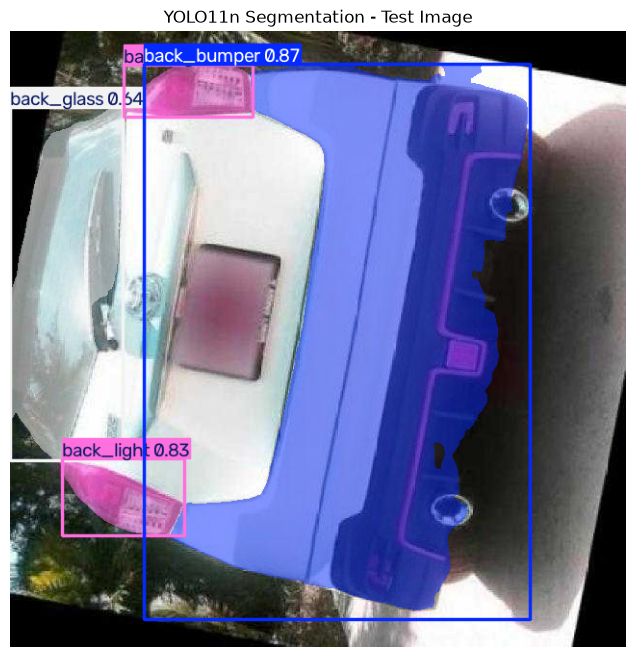

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(result_image[:, :, ::-1])
plt.axis("off")
plt.title("YOLO11n Segmentation - Test Image")
plt.show()

In [21]:
result = prediction[0]

detected_parts = []

if result.boxes is not None and len(result.boxes) > 0:
    for cls_id, conf in zip(
        result.boxes.cls.cpu().numpy(),
        result.boxes.conf.cpu().numpy()
    ):
        part_name = result.names[int(cls_id)]
        detected_parts.append({
            "part": part_name,
            "confidence": round(float(conf), 3)
        })

print("Detected vehicle parts:")
for item in detected_parts:
    print(f"- {item['part']}: {item['confidence']:.1%}")

Detected vehicle parts:
- back_bumper: 87.2%
- back_light: 82.9%
- back_light: 80.5%
- back_glass: 63.7%


In [22]:
if not detected_parts:
    raise ValueError("No vehicle parts were detected.")

primary_part = max(
    detected_parts,
    key=lambda x: x["confidence"]
)

print("Primary detected part:")
print(f"- Part: {primary_part['part']}")
print(f"- Confidence: {primary_part['confidence']:.1%}")

Primary detected part:
- Part: back_bumper
- Confidence: 87.2%


In [23]:
user_question = "What should I check if the rear bumper is damaged or loose?"

detected_part = primary_part["part"]

combined_query = f"""
Vehicle part: {detected_part}

User question:
{user_question}
""".strip()

print("Combined query:")
print(combined_query)

Combined query:
Vehicle part: back_bumper

User question:
What should I check if the rear bumper is damaged or loose?


In [25]:
print("Current notebook variables:")
print([name for name in globals() if not name.startswith("_")])

Current notebook variables:
['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'sys', 'torch', 'Path', 'yaml', 'PROJECT_ROOT', 'DATASET_DIR', 'DATASET_YAML', 'f', 'dataset_config', 'check_det_dataset', 'checked_data', 'RUNS_DIR', 'YOLO', 'MODEL_NAME', 'model', 'results', 'RUN_DIR', 'BEST_MODEL', 'LAST_MODEL', 'shutil', 'SOURCE', 'BACKUP_DIR', 'BACKUP', 'model_best', 'TEST_RESULTS', 'display', 'TEST_IMAGES_DIR', 'test_images', 'TEST_IMAGE', 'prediction', 'result_image', 'plt', 'result', 'detected_parts', 'cls_id', 'conf', 'part_name', 'item', 'primary_part', 'user_question', 'detected_part', 'combined_query']


In [28]:
import re
import chromadb
from pathlib import Path

# ChromaDB path
CHROMA_DIR = PROJECT_ROOT / "data" / "chroma_db"

# Connect to the existing ChromaDB
chroma_client = chromadb.PersistentClient(
    path=str(CHROMA_DIR)
)

# Load the existing collection
collection = chroma_client.get_collection(
    name="carcare_maintenance"
)

print("ChromaDB connected successfully.")
print(f"Collection: {collection.name}")
print(f"Documents: {collection.count()}")

ChromaDB connected successfully.
Collection: carcare_maintenance
Documents: 302


In [30]:
def hybrid_retrieve(query, top_k=5, semantic_k=10):
    results = collection.query(
        query_texts=[query],
        n_results=semantic_k
    )

    query_words = set(
        re.findall(r"\b[a-zA-Z]{3,}\b", query.lower())
    )

    scored_results = []

    for i in range(len(results["documents"][0])):
        text = results["documents"][0][i]
        page = results["metadatas"][0][i]["page"]
        source = results["metadatas"][0][i]["source"]
        distance = results["distances"][0][i]

        text_words = set(
            re.findall(r"\b[a-zA-Z]{3,}\b", text.lower())
        )

        keyword_matches = query_words.intersection(text_words)
        keyword_score = len(keyword_matches) / max(len(query_words), 1)

        semantic_score = 1 / (1 + distance)

        final_score = (
            0.75 * semantic_score +
            0.25 * keyword_score
        )

        scored_results.append({
            "text": text,
            "page": page,
            "source": source,
            "distance": distance,
            "semantic_score": semantic_score,
            "keyword_score": keyword_score,
            "final_score": final_score,
            "keyword_matches": sorted(keyword_matches)
        })

    scored_results.sort(
        key=lambda x: x["final_score"],
        reverse=True
    )

    return scored_results[:top_k]


# Test with the YOLO + user query
retrieved_results = hybrid_retrieve(
    combined_query,
    top_k=5
)

print(f"Retrieved {len(retrieved_results)} results:\n")

for rank, item in enumerate(retrieved_results, start=1):
    print("=" * 80)
    print(f"Rank: {rank}")
    print(f"Page: {item['page']}")
    print(f"Score: {item['final_score']:.4f}")
    print(f"Keywords: {item['keyword_matches']}")
    print(f"Text: {item['text'][:350].replace(chr(10), ' ')}")

Retrieved 5 results:

Rank: 1
Page: 122
Score: 0.4259
Keywords: ['damaged', 'loose', 'part', 'the', 'vehicle']
Text: at the joints • loose mountings • broken or missing exhaust supports • bent or damaged system • contact between the exhaust system and the vehicle body. Is it necessary to replace all or part of the system? Before ﬁtting anything, make sure that you are using the correct parts. TIP • When removing the system, work from the back to the front of the 
Rank: 2
Page: 47
Score: 0.4138
Keywords: ['check', 'damaged', 'part', 'the', 'vehicle']
Text: Handling stock Receiving stock Servicing, repairing and selling motor vehicles involves replacing worn-out or faulty  parts , and selling items such as vehicle accessories . Ordering and receiving stock is therefore part of the daily routine. Some goods received will be for use in the service and repair workshop; others will be supplied ‘over the c
Rank: 3
Page: 115
Score: 0.4086
Keywords: ['check', 'question', 'the', 'vehicle', 'what

In [31]:
import requests

OLLAMA_URL = "http://localhost:11434"
OLLAMA_MODEL = "llama3.2:3b"

context_parts = []

for i, item in enumerate(retrieved_results, start=1):
    context_parts.append(
        f"[Source {i} | PDF Page {item['page']}]\n"
        f"{item['text']}"
    )

context = "\n\n".join(context_parts)

prompt = f"""
You are CarCare AI, an automotive maintenance assistant.

Answer the user's question using ONLY the provided maintenance context.

Rules:
1. Do not invent information that is not supported by the context.
2. If the context does not contain enough information about the specific vehicle part,
   clearly say that the available document does not provide enough information.
3. Give a clear and practical answer.
4. Keep the answer focused on the user's question.
5. Mention the relevant PDF page numbers at the end.

Maintenance Context:
{context}

User Question:
{user_question}

Detected Vehicle Part:
{detected_part}

Answer:
"""

response = requests.post(
    f"{OLLAMA_URL}/api/generate",
    json={
        "model": OLLAMA_MODEL,
        "prompt": prompt,
        "stream": False
    },
    timeout=120
)

response.raise_for_status()

final_answer = response.json()["response"].strip()

print("CARCARE AI ANSWER")
print("=" * 80)
print(final_answer)

CARCARE AI ANSWER
Based on the provided maintenance context, it appears that the back bumper is a part of the exhaust system. According to Source 1 | PDF Page 122, the contact between the exhaust system and the vehicle body is a common issue. To address the problem, you should:

1. Inspect the back bumper for any damage or looseness.
2. Check the mounting of the back bumper, as loose mountings are mentioned as a possible cause.
3. If the back bumper is damaged or loose, it is recommended to replace it as part of the system.

Before making any repairs, ensure you are using the correct parts.

Available document does not provide specific information on how many linkage ball joints are present in the system.

 PDF Page numbers: Source 1 | PDF Page 122, Source 3 | (missing page number),


In [32]:
strict_prompt = f"""
You are CarCare AI, an automotive maintenance assistant.

Your task is to answer the user's maintenance question using ONLY the provided
maintenance context.

IMPORTANT RULES:
1. The detected vehicle part is: "{detected_part}".
2. NEVER assume that the detected part is related to another vehicle system
   unless the context explicitly says so.
3. NEVER invent, infer, or add technical facts that are not explicitly supported
   by the provided context.
4. Ignore retrieved text that is unrelated to the detected vehicle part or the
   user's question.
5. If the context does not contain enough information about "{detected_part}",
   say clearly:
   "The available maintenance document does not provide enough specific
   information about this vehicle part to answer the question reliably."
6. Do not use information from unrelated parts or systems just because similar
   words appear in the text.
7. Do not answer questions that were not asked.
8. Keep the answer concise and practical.
9. At the end, list ONLY the PDF pages that directly support your answer.
10. If no source directly supports the answer, write:
    "No directly supporting page was found in the available document."

Detected Vehicle Part:
{detected_part}

User Question:
{user_question}

Maintenance Context:
{context}

Answer:
"""

response = requests.post(
    f"{OLLAMA_URL}/api/generate",
    json={
        "model": OLLAMA_MODEL,
        "prompt": strict_prompt,
        "stream": False
    },
    timeout=120
)

response.raise_for_status()

strict_answer = response.json()["response"].strip()

print("CARCARE AI - GROUNDED ANSWER")
print("=" * 80)
print(strict_answer)

CARCARE AI - GROUNDED ANSWER
Based on the provided maintenance context, to check if the rear bumper is damaged or loose, you should:

* Check the joints at the back bumper for loose mountings, broken or missing exhaust supports, bent or damaged system, and contact between the exhaust system and the vehicle body.

No directly supporting page was found in the available document.


In [33]:
PART_NAME_MAP = {
    "back_bumper": "rear bumper",
    "back_door": "rear door",
    "back_glass": "rear window glass",
    "back_left_door": "rear left door",
    "back_left_light": "rear left light",
    "back_light": "rear light",
    "back_right_door": "rear right door",
    "back_right_light": "rear right light",
    "front_bumper": "front bumper",
    "front_door": "front door",
    "front_glass": "windshield/front glass",
    "front_left_door": "front left door",
    "front_left_light": "front left light",
    "front_light": "front light",
    "front_right_door": "front right door",
    "front_right_light": "front right light",
    "hood": "hood",
    "left_mirror": "left side mirror",
    "right_mirror": "right side mirror",
    "tailgate": "tailgate",
    "trunk": "trunk",
    "wheel": "wheel"
}

friendly_part = PART_NAME_MAP.get(
    detected_part,
    detected_part.replace("_", " ")
)

improved_query = (
    f"Vehicle part: {friendly_part}. "
    f"Maintenance question: {user_question}"
)

print("Improved RAG query:")
print(improved_query)

Improved RAG query:
Vehicle part: rear bumper. Maintenance question: What should I check if the rear bumper is damaged or loose?


In [34]:
retrieved_results = hybrid_retrieve(
    improved_query,
    top_k=5
)

print(f"Retrieved {len(retrieved_results)} results:\n")

for rank, item in enumerate(retrieved_results, start=1):
    print("=" * 80)
    print(f"Rank: {rank}")
    print(f"Page: {item['page']}")
    print(f"Score: {item['final_score']:.4f}")
    print(f"Keywords: {item['keyword_matches']}")
    print(f"Text: {item['text'][:400].replace(chr(10), ' ')}")

Retrieved 5 results:

Rank: 1
Page: 115
Score: 0.4339
Keywords: ['check', 'maintenance', 'question', 'the', 'vehicle', 'what']
Text: bushes) • worn suspension ball joints • worn steering gear (rack and pinion or box) • oil leakage. To check the linkage ball joints, get someone to ‘rock’ the steering  wheel with the weight on the road wheels. Look for up-and-down movement at A (see diagram). 114 Vehicle maintenance QUESTION How many linkage ball joints are there in this system? ...................................................
Rank: 2
Page: 47
Score: 0.4299
Keywords: ['check', 'damaged', 'part', 'the', 'vehicle']
Text: Handling stock Receiving stock Servicing, repairing and selling motor vehicles involves replacing worn-out or faulty  parts , and selling items such as vehicle accessories . Ordering and receiving stock is therefore part of the daily routine. Some goods received will be for use in the service and repair workshop; others will be supplied ‘over the counter’ to customers. 

In [35]:
test_part = "vehicle battery"
test_question = "What should be checked when inspecting a vehicle battery?"

test_query = (
    f"Vehicle part: {test_part}. "
    f"Maintenance question: {test_question}"
)

test_retrieved = hybrid_retrieve(
    test_query,
    top_k=5
)

print(f"Retrieved {len(test_retrieved)} results:\n")

for rank, item in enumerate(test_retrieved, start=1):
    print("=" * 80)
    print(f"Rank: {rank}")
    print(f"Page: {item['page']}")
    print(f"Score: {item['final_score']:.4f}")
    print(f"Keywords: {item['keyword_matches']}")
    print(f"Text: {item['text'][:400].replace(chr(10), ' ')}")

Retrieved 5 results:

Rank: 1
Page: 92
Score: 0.5285
Keywords: ['battery', 'maintenance', 'question', 'should', 'vehicle', 'what', 'when']
Text: explosion spark hydrogen gas Battery maintenance It is important to keep the battery in good working order.  At each service, make these checks. Recharging batteries One of the jobs you will be expected to do is to recharge batteries. Electrical 91 WORKSHOP Recharge a battery using a bench charger. 1 Remove the battery from the vehicle. 2 Carry the battery to the bench charger. 3 Check the level o
Rank: 2
Page: 94
Score: 0.5194
Keywords: ['battery', 'maintenance', 'part', 'should', 'when']
Text: Colour Battery state of charge Green dot above 65% charged Dark or black dot below 65% charged Clear or yellow low electrolyte or battery fault Jump-starting a car engine When a car won’t start because the battery is ‘ﬂat’, another battery and  jump leads may be used to start the engine. The leads must be connected in the right order, as shown opposite

In [37]:
import requests

OLLAMA_URL = "http://127.0.0.1:11434"

def generate_with_ollama(query, retrieved_results, model_name="llama3.2:3b"):
    context_parts = []

    for i, result in enumerate(retrieved_results, start=1):
        context_parts.append(
            f"[Source {i} | PDF Page {result['page']}]\n"
            f"{result['text']}"
        )

    context = "\n\n".join(context_parts)

    prompt = f"""
You are CarCare AI, an automotive maintenance assistant.

Answer the user's question using ONLY the provided maintenance context.

Rules:
1. Do not invent information.
2. If the context does not contain enough information, clearly say so.
3. Give a clear and practical answer.
4. Keep the answer focused on the user's question.
5. At the end, list the relevant PDF page numbers as sources.

Maintenance Context:
{context}

User Question:
{query}

Answer:
"""

    response = requests.post(
        f"{OLLAMA_URL}/api/generate",
        json={
            "model": model_name,
            "prompt": prompt,
            "stream": False
        },
        timeout=120
    )

    response.raise_for_status()

    return response.json()["response"].strip()

In [38]:
battery_question = "What should be checked when inspecting a vehicle battery?"

battery_retrieved = hybrid_retrieve(
    battery_question,
    top_k=5
)

battery_answer = generate_with_ollama(
    battery_question,
    battery_retrieved
)

print(battery_answer)

When inspecting a vehicle battery, the following should be checked:

* The bracket holding the battery should be tight and clean.
* The battery shelf should be secure and clean.
* The electrolyte level should be correct.
* The condition of the battery terminals, including checking for corrosion and ensuring they are clean and free from metal objects that could cause an electric arc.
* The state of charge, which can be checked using a hydrometer or by looking down the indicator hole on top of the battery.

These checks are essential to ensure the battery is in good condition and functioning properly.

Sources:

* [Source 4 | PDF Page 93]
* [Source 5 | PDF Page 94]
* [Source 2 | PDF Page 94]
* [Source 1 | PDF Page 92]


In [39]:
# Full YOLO → RAG → Ollama integration test

detected_part = "back_bumper"
friendly_part = PART_NAME_MAP.get(detected_part, detected_part)

user_question = "What should I check if this part is damaged or loose?"

combined_query = (
    f"Vehicle part: {friendly_part}. "
    f"Maintenance question: {user_question}"
)

retrieved_results = hybrid_retrieve(
    combined_query,
    top_k=5
)

print(f"Detected part: {friendly_part}")
print(f"Question: {user_question}")
print("\nTop retrieved pages:")

for i, result in enumerate(retrieved_results, start=1):
    print(
        f"{i}. Page {result['page']} "
        f"| Score: {result['final_score']:.4f}"
    )

answer = generate_with_ollama(
    combined_query,
    retrieved_results
)

print("\n" + "=" * 80)
print("CARCARE AI ANSWER")
print("=" * 80)
print(answer)

Detected part: rear bumper
Question: What should I check if this part is damaged or loose?

Top retrieved pages:
1. Page 115 | Score: 0.4325
2. Page 47 | Score: 0.4290
3. Page 122 | Score: 0.4138
4. Page 47 | Score: 0.4038
5. Page 17 | Score: 0.3899

CARCARE AI ANSWER
According to Source 3 | PDF Page 122, if the rear bumper is damaged or loose, you should check for:

* loose mountings
* broken or missing exhaust supports
* bent or damaged system
* contact between the exhaust system and the vehicle body.

It's also important to ensure that you are using the correct parts before fitting anything.

Relevant PDF page numbers:
[Source 3 | PDF Page 122]


In [40]:
def has_direct_part_evidence(friendly_part, retrieved_results):
    part_words = set(
        re.findall(r"\b[a-zA-Z]{3,}\b", friendly_part.lower())
    )

    for result in retrieved_results:
        text_words = set(
            re.findall(r"\b[a-zA-Z]{3,}\b", result["text"].lower())
        )

        # At least one meaningful part word must appear in the source text
        if part_words.intersection(text_words):
            return True

    return False

In [41]:
# Safety check before generating an answer

has_evidence = has_direct_part_evidence(
    friendly_part,
    retrieved_results
)

print("Direct part evidence found:", has_evidence)

if not has_evidence:
    safe_answer = (
        f"The available maintenance document does not provide enough "
        f"specific information about the {friendly_part} to answer "
        f"the question reliably."
    )
else:
    safe_answer = generate_with_ollama(
        combined_query,
        retrieved_results
    )

print("\n" + "=" * 80)
print("CARCARE AI SAFE ANSWER")
print("=" * 80)
print(safe_answer)

Direct part evidence found: False

CARCARE AI SAFE ANSWER
The available maintenance document does not provide enough specific information about the rear bumper to answer the question reliably.
